In [ ]:
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.drivers import PySCFDriver


print("=" * 60)
print("VQE for H2 Molecule on simulator")
print("=" * 60)

# ---- Step 1: Generate H2 Hamiltonian ----
print("\n[1/5] Generating H2 Hamiltonian...")
driver = PySCFDriver(atom='H 0 0 0; H 0 0 0.74', basis='sto3g')
problem = driver.run()
mapper = JordanWignerMapper()
hamiltonian = mapper.map(problem.hamiltonian.second_q_op())

print(f"  ✓ Number of qubits: {hamiltonian.num_qubits}")
print(f"  ✓ Number of Pauli terms: {len(hamiltonian)}")

VQE for H2 Molecule on simulator

[1/5] Generating H2 Hamiltonian...
  ✓ Number of qubits: 4
  ✓ Number of Pauli terms: 15


In [2]:
expected_energy = -1.1373060357533986 # Ha

This circuit has  8 parameters


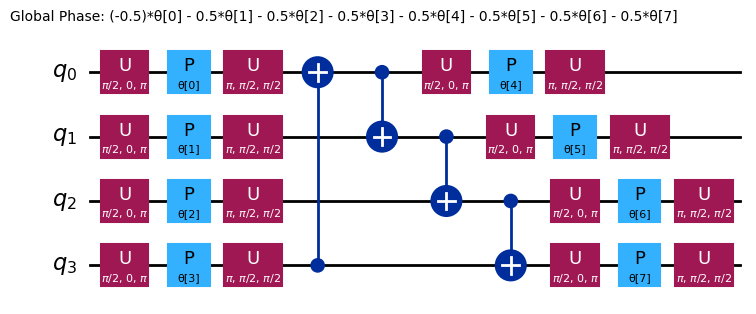

In [3]:
# Pre-defined ansatz circuit and operator class for Hamiltonian
from qiskit.circuit.library import efficient_su2
 
# Note that it is more common to place initial 'h' gates outside the ansatz. Here we specifically wanted this layer structure.
ansatz = efficient_su2(
    hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], entanglement="circular", reps=1
)
num_params = ansatz.num_parameters
print("This circuit has ", num_params, "parameters")
 
ansatz.decompose().draw("mpl", style="iqp")

In [4]:
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    Session,
    EstimatorV2 as Estimator,
)
 
service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False)


from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3
)



pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_ansatz = pm.run(ansatz)
isa_hamiltonian = hamiltonian.apply_layout(isa_ansatz.layout)

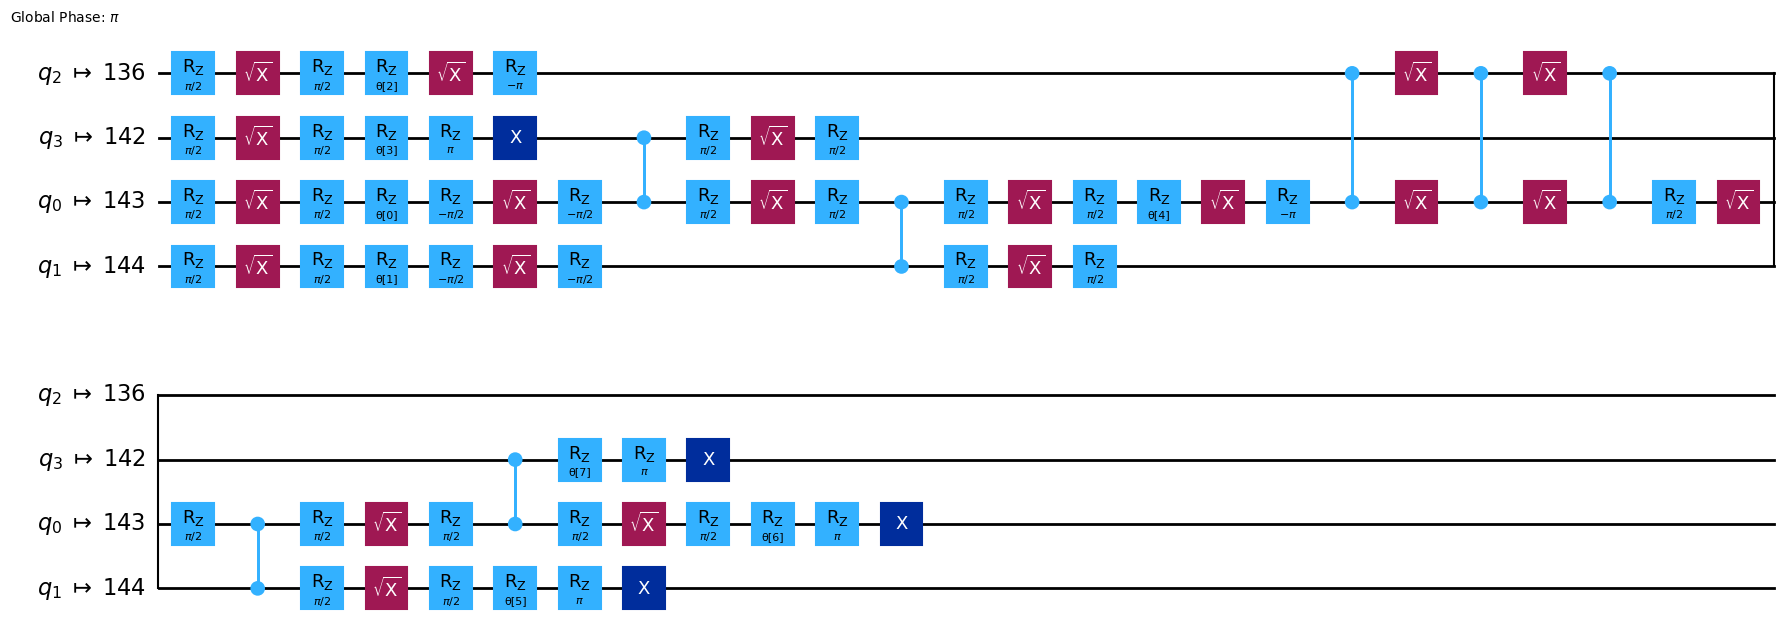

In [5]:
isa_ansatz.draw("mpl", style="iqp")

In [ ]:
from scipy.optimize import minimize
import numpy as np

import sys, os

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, ".."))
if project_root not in sys.path:
    sys.path.append(project_root)


from methods.methods import cost_function

iterations = [0]
file_name = "qc_h2.csv"
initial_params = np.zeros(isa_ansatz.num_parameters)



In [10]:
from scipy.optimize import minimize
import numpy as np

initial_params = np.zeros(num_params)

with Session(backend=backend) as session:
  
    print(f"\nStarting optimization\n")
    
    result = minimize(
        cost_function,
        initial_params,
        method="COBYLA",  # Derivative-free optimizer
        args=(problem,isa_hamiltonian, isa_ansatz, file_name, iterations,Estimator, session),
        options={
            "maxiter": 100,      # Maximum iterations
            "tol": 1e-5         # Convergence tolerance
        }
    )


Starting optimization

Iteration 1: Evaluating cost function...
  Energy: 0.340479 Ha
Iteration 2: Evaluating cost function...
  Energy: 0.179607 Ha
Iteration 3: Evaluating cost function...
  Energy: 0.120939 Ha
Iteration 4: Evaluating cost function...
  Energy: 0.084955 Ha
Iteration 5: Evaluating cost function...
  Energy: -0.015850 Ha
Iteration 6: Evaluating cost function...
  Energy: -0.019953 Ha
Iteration 7: Evaluating cost function...
  Energy: -0.016673 Ha
Iteration 8: Evaluating cost function...
  Energy: -0.034151 Ha
Iteration 9: Evaluating cost function...
  Energy: -0.034583 Ha
Iteration 10: Evaluating cost function...
  Energy: -0.128000 Ha
Iteration 11: Evaluating cost function...
  Energy: -0.030171 Ha
Iteration 12: Evaluating cost function...
  Energy: -0.067050 Ha
Iteration 13: Evaluating cost function...
  Energy: -0.008903 Ha
Iteration 14: Evaluating cost function...
  Energy: -0.112855 Ha
Iteration 15: Evaluating cost function...
  Energy: -0.362032 Ha
Iteration 16: 